In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [4]:
import os

spark = SparkSession.builder \
    .appName("DemandAnalysis") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", os.environ.get("MINIO_ENDPOINT", "http://minio:9000")) \
    .config("spark.hadoop.fs.s3a.access.key", os.environ.get("MINIO_ROOT_USER", "minioadmin")) \
    .config("spark.hadoop.fs.s3a.secret.key", os.environ.get("MINIO_ROOT_PASSWORD", "minioadmin")) \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

# Now your code will work
df = spark.read.parquet("s3a://processed/demand_cleaned")
df.show()

+------------+----------------+------------+----------+-----------------+------------------+------------------+--------------+----------+-----------------+----+-----+-----------+------------+----------+---------+
|Product_Code|Product_Category|Order_Demand|      Date|date_parse_failed|demand_cast_failed|is_negative_demand|is_zero_demand|is_outlier|is_sparse_product|year|month|day_of_week|week_of_year|year_month|Warehouse|
+------------+----------------+------------+----------+-----------------+------------------+------------------+--------------+----------+-----------------+----+-----+-----------+------------+----------+---------+
|PRODUCT_1159|    CATEGORY_006|       50000|2012-03-09|            false|             false|             false|         false|      true|            false|2012|    3|          6|          10|   2012-03|   WHSE_J|
|PRODUCT_1159|    CATEGORY_006|       50000|2012-06-20|            false|             false|             false|         false|      true|           

## Data selection

In [5]:
df.count()

924272

In [6]:
display(df.limit(20).toPandas())

,Product_Code,Product_Category,Order_Demand,Date,date_parse_failed,demand_cast_failed,is_negative_demand,is_zero_demand,is_outlier,is_sparse_product,year,month,day_of_week,week_of_year,year_month,Warehouse
0,PRODUCT_1159,CATEGORY_006,50000,2012-03-09,False,False,False,False,True,False,2012,3,6,10,2012-03,WHSE_J
1,PRODUCT_1159,CATEGORY_006,50000,2012-06-20,False,False,False,False,True,False,2012,6,4,25,2012-06,WHSE_J
2,PRODUCT_1938,CATEGORY_001,4,2012-06-06,False,False,False,False,False,False,2012,6,4,23,2012-06,WHSE_J
3,PRODUCT_1157,CATEGORY_006,160000,2012-08-09,False,False,False,False,True,False,2012,8,5,32,2012-08,WHSE_J
4,PRODUCT_1274,CATEGORY_019,1000,2012-01-16,False,False,False,False,False,False,2012,1,2,3,2012-01,WHSE_J
5,PRODUCT_1512,CATEGORY_019,20000,2012-04-20,False,False,False,False,True,False,2012,4,6,16,2012-04,WHSE_J
6,PRODUCT_1512,CATEGORY_019,30000,2012-07-04,False,False,False,False,True,False,2012,7,4,27,2012-07,WHSE_J
7,PRODUCT_1451,CATEGORY_019,1000,2012-07-24,False,False,False,False,False,False,2012,7,3,30,2012-07,WHSE_J
8,PRODUCT_1512,CATEGORY_019,60000,2012-09-12,False,False,False,False,True,False,2012,9,4,37,2012-09,WHSE_J
9,PRODUCT_1970,CATEGORY_005,3000,2012-11-29,False,False,False,False,False,False,2012,11,5,48,2012-11,WHSE_J


In [7]:
selected = ["Product_Code", "Product_Category", "Order_Demand", "Date", "day_of_week", "week_of_year"]
df_selected = df.select(*selected)
df_selected

DataFrame[Product_Code: string, Product_Category: string, Order_Demand: bigint, Date: date, day_of_week: int, week_of_year: int]

In [8]:
display(df.limit(20).toPandas())

,Product_Code,Product_Category,Order_Demand,Date,date_parse_failed,demand_cast_failed,is_negative_demand,is_zero_demand,is_outlier,is_sparse_product,year,month,day_of_week,week_of_year,year_month,Warehouse
0,PRODUCT_1159,CATEGORY_006,50000,2012-03-09,False,False,False,False,True,False,2012,3,6,10,2012-03,WHSE_J
1,PRODUCT_1159,CATEGORY_006,50000,2012-06-20,False,False,False,False,True,False,2012,6,4,25,2012-06,WHSE_J
2,PRODUCT_1938,CATEGORY_001,4,2012-06-06,False,False,False,False,False,False,2012,6,4,23,2012-06,WHSE_J
3,PRODUCT_1157,CATEGORY_006,160000,2012-08-09,False,False,False,False,True,False,2012,8,5,32,2012-08,WHSE_J
4,PRODUCT_1274,CATEGORY_019,1000,2012-01-16,False,False,False,False,False,False,2012,1,2,3,2012-01,WHSE_J
5,PRODUCT_1512,CATEGORY_019,20000,2012-04-20,False,False,False,False,True,False,2012,4,6,16,2012-04,WHSE_J
6,PRODUCT_1512,CATEGORY_019,30000,2012-07-04,False,False,False,False,True,False,2012,7,4,27,2012-07,WHSE_J
7,PRODUCT_1451,CATEGORY_019,1000,2012-07-24,False,False,False,False,False,False,2012,7,3,30,2012-07,WHSE_J
8,PRODUCT_1512,CATEGORY_019,60000,2012-09-12,False,False,False,False,True,False,2012,9,4,37,2012-09,WHSE_J
9,PRODUCT_1970,CATEGORY_005,3000,2012-11-29,False,False,False,False,False,False,2012,11,5,48,2012-11,WHSE_J


## Some stats

In [9]:
df_selected.describe().show()

+-------+------------+----------------+------------------+------------------+------------------+
|summary|Product_Code|Product_Category|      Order_Demand|       day_of_week|      week_of_year|
+-------+------------+----------------+------------------+------------------+------------------+
|  count|      924272|          924272|            924272|            924272|            924272|
|   mean|        NULL|            NULL| 5087.325710396939|3.9725578617549813|26.642197318538265|
| stddev|        NULL|            NULL|30459.365244761928| 1.421456021408842|14.975115805452273|
|    min|PRODUCT_0001|    CATEGORY_001|           -999000|                 1|                 1|
|    max|PRODUCT_2172|    CATEGORY_033|           4000000|                 7|                53|
+-------+------------+----------------+------------------+------------------+------------------+



## Visualizations

In [28]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns

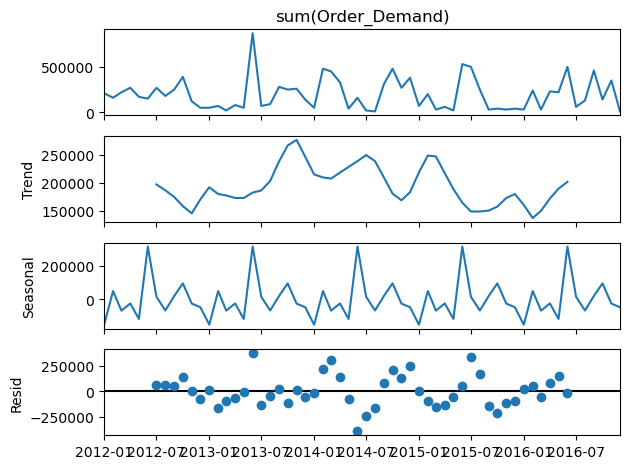

In [13]:
# Filter to one high-demand product and aggregate by month to smooth noise
single_prod = df.filter(df.Product_Code == "PRODUCT_1159") \
                .groupBy("year_month").agg({"Order_Demand": "sum"}) \
                .toPandas().sort_values("year_month")

single_prod.index = pd.to_datetime(single_prod["year_month"])
result = seasonal_decompose(single_prod["sum(Order_Demand)"], model='additive', period=12)

result.plot()
plt.show()

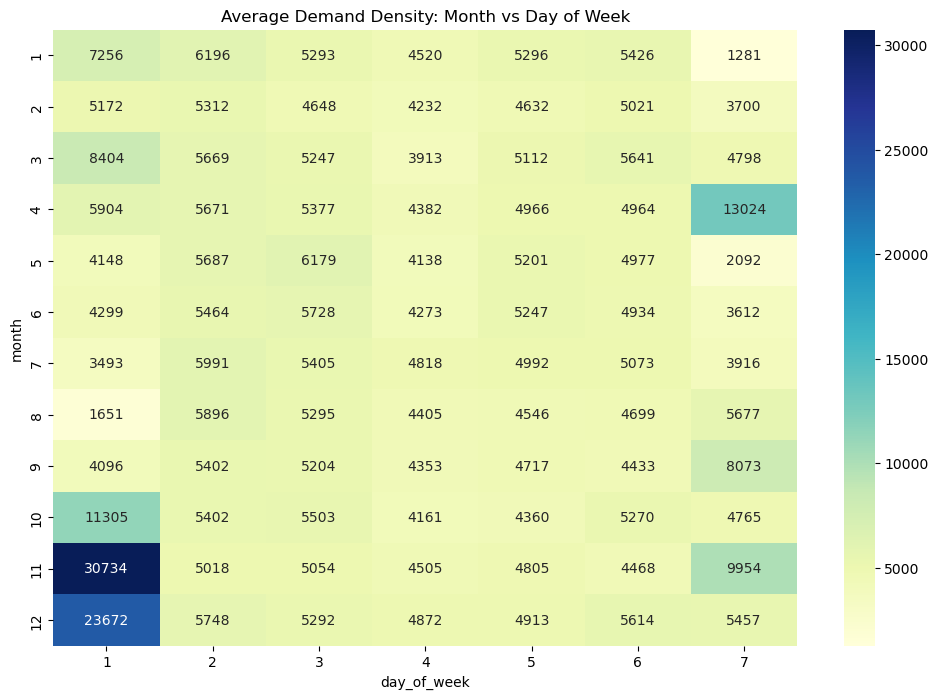

In [16]:
# Aggregate demand by month and day of week
heatmap_data = df.groupBy("month", "day_of_week").avg("Order_Demand").toPandas()
pivot_table = heatmap_data.pivot(index="month", columns="day_of_week", values="avg(Order_Demand)")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Demand Density: Month vs Day of Week")
plt.show()

The heatmap reveals a massive surge in average demand on the first day of the week (Monday) during October, November, and December. Specifically, November shows a peak of 30,734, which is nearly 6x the typical daily demand seen midweek.

In [18]:
from pyspark.sql import functions as F

# Filter specifically for Mondays (1) in Q4 (10, 11, 12)
q4_mondays = df.filter(
    (F.col("day_of_week") == 1) & 
    (F.col("month").isin(10, 11, 12))
)

# Insight 1: Is it one specific Warehouse causing the spike?
warehouse_impact = q4_mondays.groupBy("Warehouse").agg(
    F.avg("Order_Demand").alias("avg_monday_demand"),
    F.count("*").alias("row_count")
).orderBy(F.desc("avg_monday_demand"))

# Insight 2: Which categories are driving this volume?
category_impact = q4_mondays.groupBy("Product_Category").agg(
    F.sum("Order_Demand").alias("total_q4_monday_volume")
).orderBy(F.desc("total_q4_monday_volume"))

warehouse_impact.show()
category_impact.limit(10).show()

+---------+------------------+---------+
|Warehouse| avg_monday_demand|row_count|
+---------+------------------+---------+
|   WHSE_C| 42305.01724137931|       58|
|   WHSE_S|  30820.5073800738|     1084|
|   WHSE_J| 6117.202777777778|      360|
|   WHSE_A|2810.5023255813953|      215|
+---------+------------------+---------+

+----------------+----------------------+
|Product_Category|total_q4_monday_volume|
+----------------+----------------------+
|    CATEGORY_019|              34407256|
|    CATEGORY_006|               1591412|
|    CATEGORY_005|               1311350|
|    CATEGORY_030|                506900|
|    CATEGORY_028|                325340|
|    CATEGORY_032|                192344|
|    CATEGORY_007|                160831|
|    CATEGORY_020|                 57468|
|    CATEGORY_009|                 51814|
|    CATEGORY_023|                 22566|
+----------------+----------------------+



WHSE_C is an extreme outlier with an average of 42,305 units per order. With only 58 rows, these are likely massive, specialized bulk shipments.

WHSE_S is the primary contributor to your volume, maintaining a high average of 30,820 over 1,084 rows. This warehouse likely serves as the main Q4 distribution hub for your network.

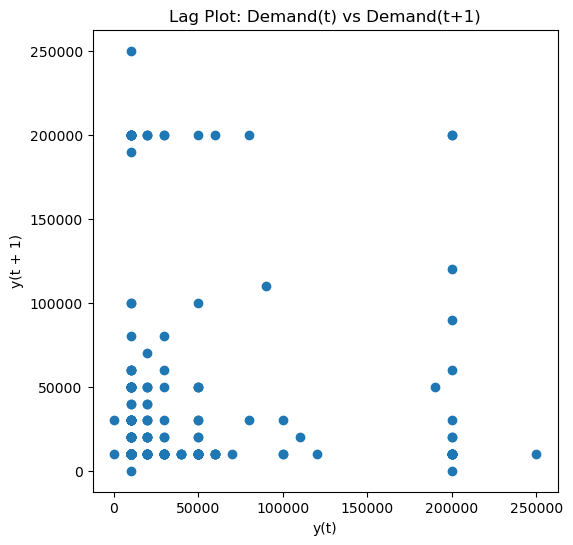

In [17]:
from pandas.plotting import lag_plot

# Select a continuous time series for one product
lag_data = df.filter(df.Product_Code == "PRODUCT_1159") \
             .orderBy("Date").select("Order_Demand").toPandas()

plt.figure(figsize=(6, 6))
lag_plot(lag_data['Order_Demand'])
plt.title("Lag Plot: Demand(t) vs Demand(t+1)")
plt.show()

Demand at time $T$ is a relatively weak predictor for demand at $T+1$. This suggests the demand is stochastic or driven by external factors (like promotions or inventory cycles) rather than simple momentum.

In [21]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.4/449.4 kB 3.2 MB/s eta 0:00:0000:0100:01


/tmp/ipykernel_1148/2876378603.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Product_Category", y="Total_Demand", data=pareto_df, ax=ax1, palette="viridis")
/tmp/ipykernel_1148/2876378603.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


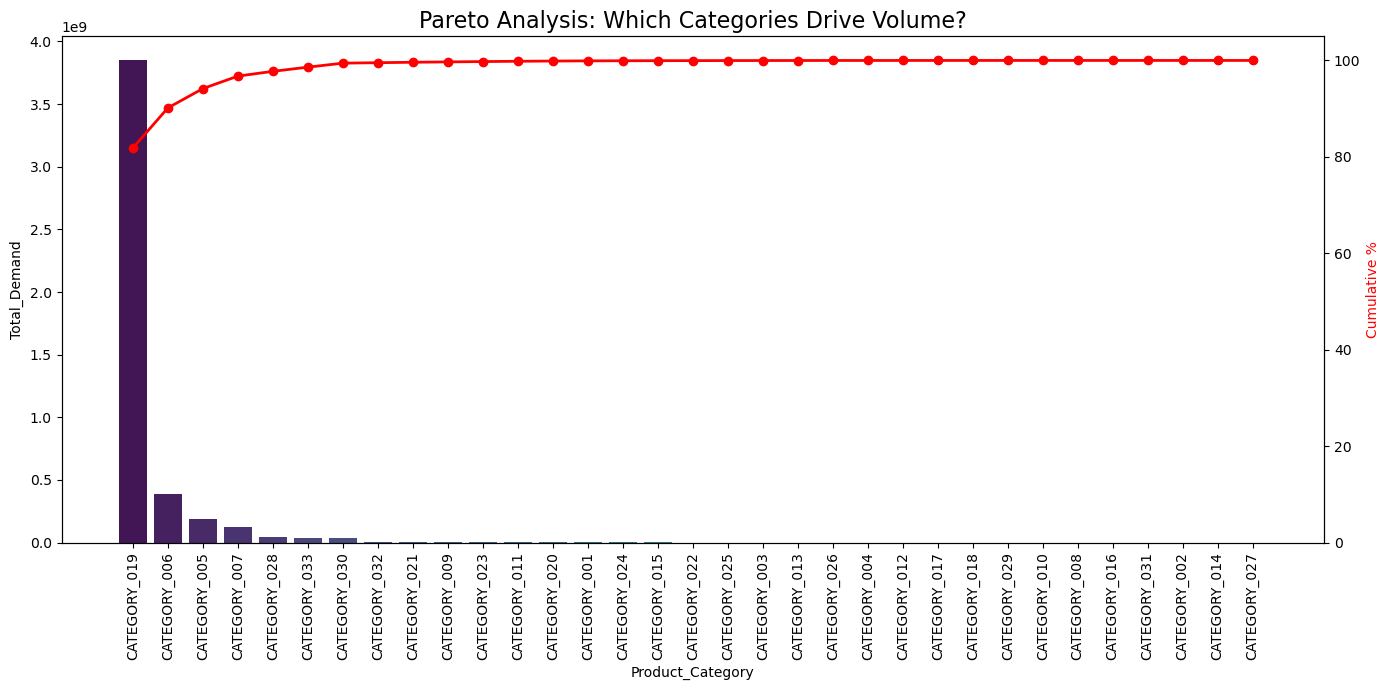

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure your pareto_df is sorted
pareto_df = pareto_df.sort_values(by="Total_Demand", ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Bar Chart for Total Demand
sns.barplot(x="Product_Category", y="Total_Demand", data=pareto_df, ax=ax1, palette="viridis")
ax1.set_title("Pareto Analysis: Which Categories Drive Volume?", fontsize=16)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

# 2. Line Chart for Cumulative Percentage (Second Y-Axis)
ax2 = ax1.twinx()
ax2.plot(pareto_df["Product_Category"], pareto_df["Cumulative_Percentage"], color="red", marker="o", linewidth=2)
ax2.set_ylabel("Cumulative %", color="red")
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

This suggests that the "health" of your entire supply chain—and the accuracy of your AI model—depends almost entirely on how well you predict this single category.

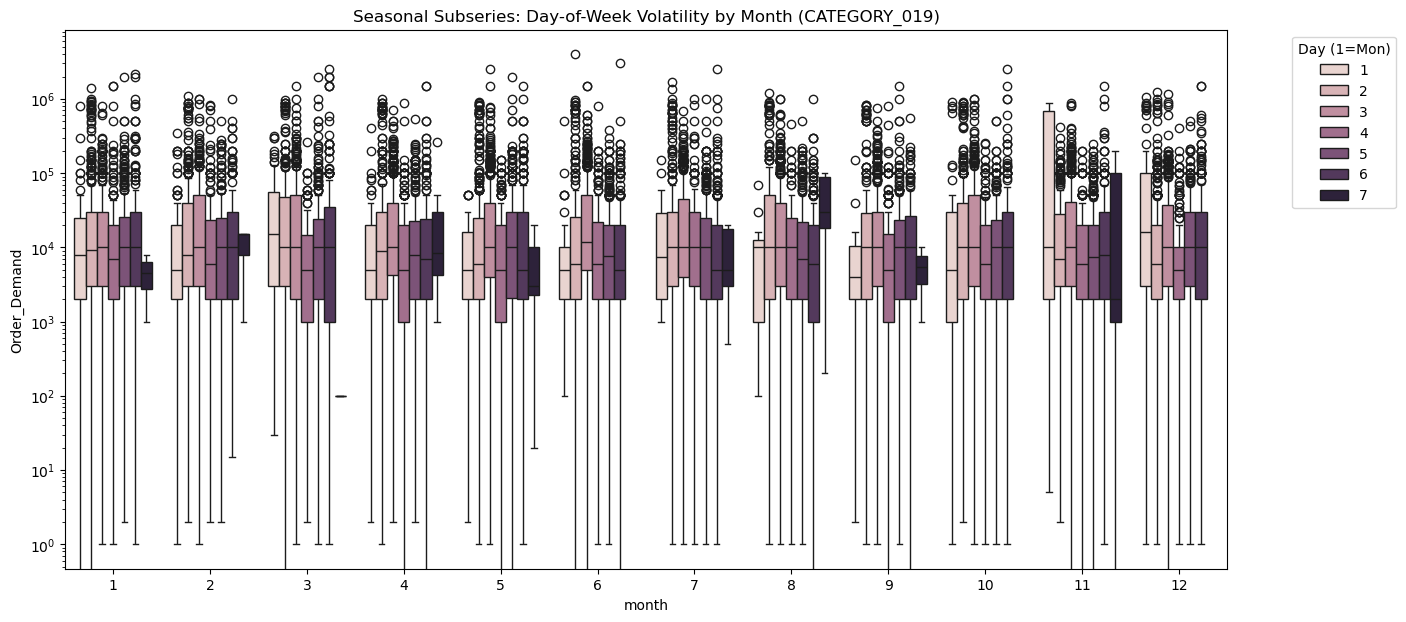

In [30]:
# Filter for the 'Whale' category in the peak warehouse
subseries_df = df.filter((df.Product_Category == "CATEGORY_019") & 
                         (df.Warehouse == "WHSE_S")).toPandas()

plt.figure(figsize=(15, 7))
sns.boxplot(data=subseries_df, x='month', y='Order_Demand', hue='day_of_week')
plt.yscale('log')
plt.title("Seasonal Subseries: Day-of-Week Volatility by Month (CATEGORY_019)")
plt.legend(title='Day (1=Mon)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

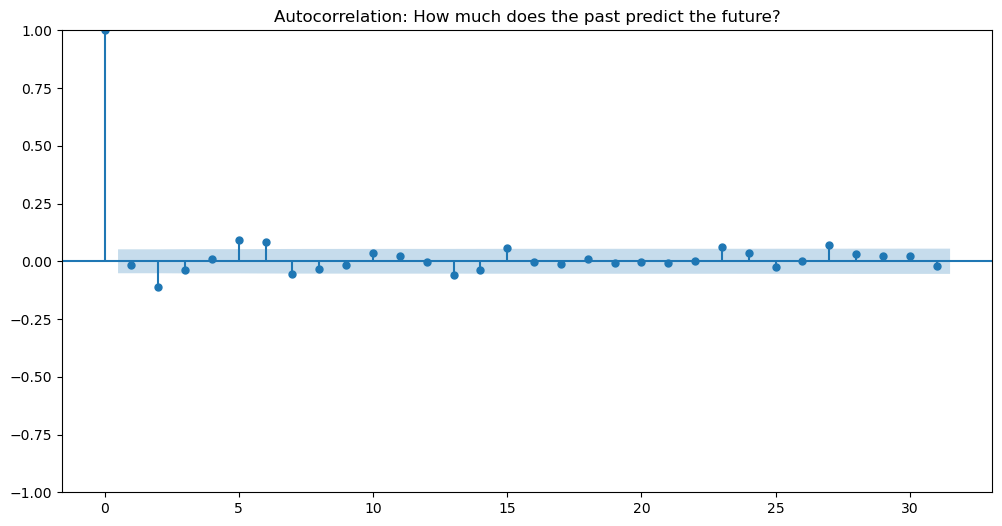

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

# Aggregate to daily total for a clean signal
daily_signal = subseries_df.groupby('Date')['Order_Demand'].sum()

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(daily_signal, lags=31, ax=ax) # Look at a full month of lags
plt.title("Autocorrelation: How much does the past predict the future?")
plt.show()